# Import dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import matplotlib
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
import joblib
color_palette = ["#440154", "#482677", "#404788", "#33638d", "#287d8e",
"#1f968b", '#29af7f', '#55c667', '#73d055', '#b8de29', '#fde725']
fp = matplotlib.font_manager.FontProperties(fname='/Fonts/roboto/Roboto-Condensed.ttf')
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

# Exploratory Data Analysis

---

This exploratory data analysis is started by importing the research_centers.csv in pandas. By using the .info() method, it can be seen that there are 50 rows in the dataset and are no missing values. Each row represents a research center and there location. There are 10 columns in the data where seven of them are numerical and the rest are of object types.

To confirm if there are duplicates, the .duplicated().any() method was used and it shows that there are no duplicated rows in our dataset. 

The histogram as shown below was plotted to understand three numerical columns which are 'internalFacilitiesCount' (Number of internal facilities (e.g., labs, testing units, workstations)), 'facilityDiversity_10km' - (Diversity index (0–1) representing how varied nearby facilities are) and 'facilityDensity_10km' (Approximate density of nearby facilities per area). 

The observation shows that 'internalFacilitiesCount' are roughly uniform distribution ranging from 1 to 11, with slight peaks at 2, 3, 4, and 10. No strong skew, suggesting a good spread of low to high-quality centers. 'facilityDiversity_10km'  spread across the full 0–1 range with a notable peak around 0.3, then relatively even distribution towards 1.0. Indicates varied diversity levels across centers.'facilityDensity_10km' concentrated in the lower range (0.1–0.6) with most values below 0.6, suggesting the majority of centers are in areas of moderate to low facility density.

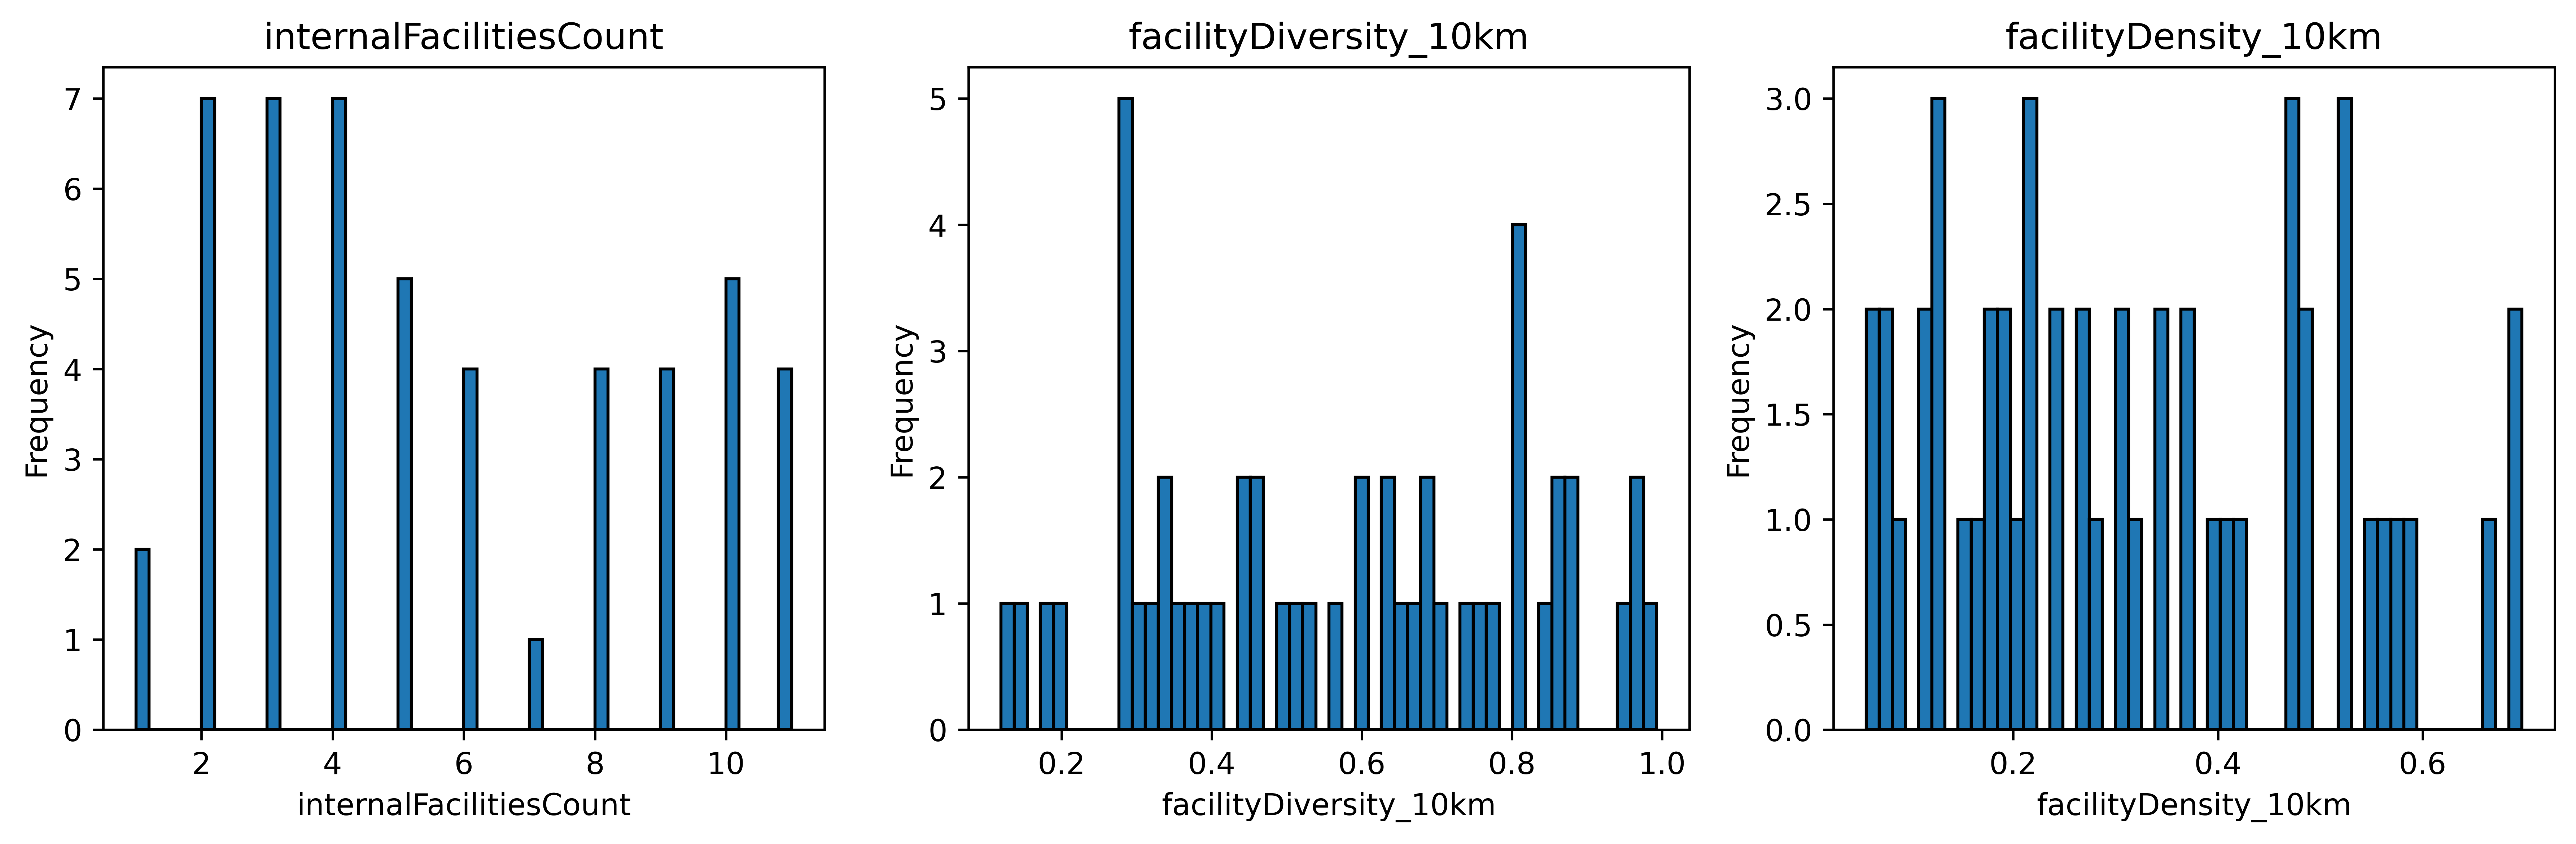

From the heatmap below, it is very clear that both longitude and latitude have very low correlations with other variables. This is not surprising as they are coordinates and they will therefore be dropped from the analysis going forward. 
?
The other five numerical data types all have high correlation coefficients with the lowest at 0.80. However, Internal Facilities Count have higher correlation to each of the other variables with its lowest at 0.88 and highest at 0.90.Internal Facilities Count has the highest correlation with both overall facility diversity and facility density with the correlation coefficient at 0.9 respectively. This is not surprisng as there would be more labs, workstationsetc in an area with more facilities of different types.  This shows that this variable might have the highest impact on our proposed model(Kmeans). This will be verified with VarianceThreshold function which is a filtering method both before and after training the model.

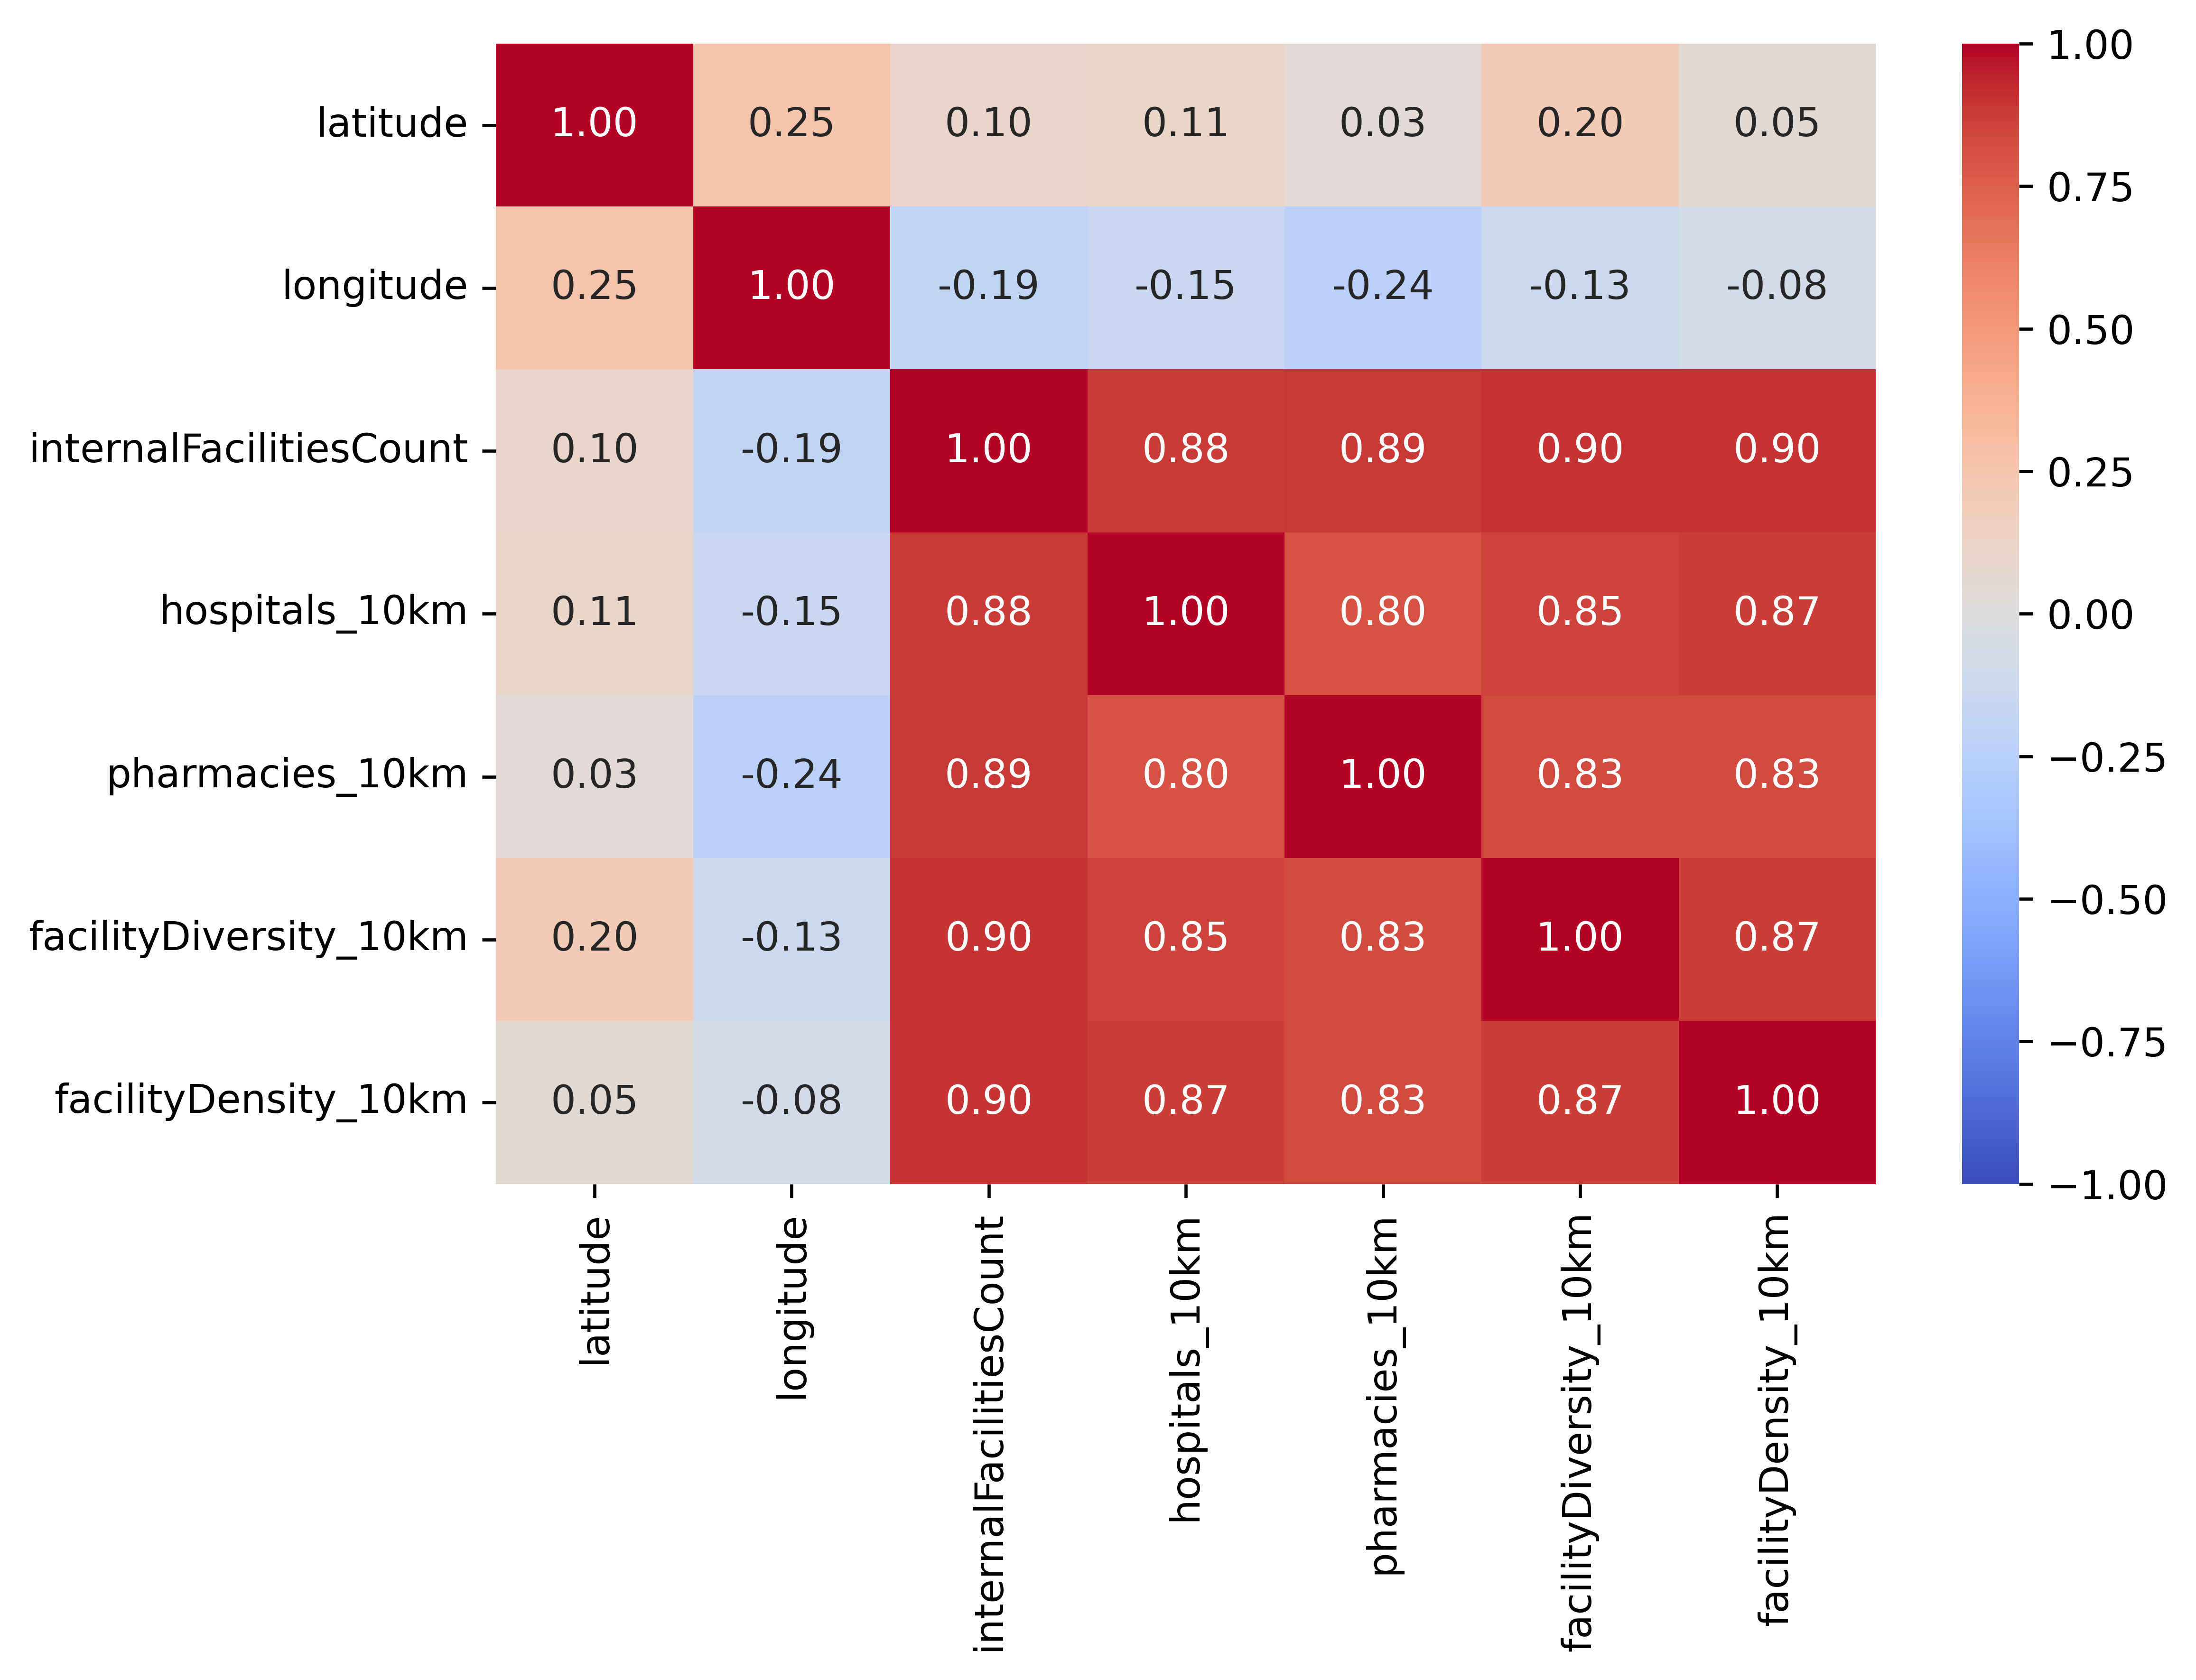

There is a clear positive relationship between hospitals_10km and pharmacies_10km — centers with more nearby hospitals also tend to have more nearby pharmacies, consistent with the 0.80 correlation seen in the heatmap 
Centers with 0 hospitals nearby have at most 1 pharmacy, indicating areas with poor overall healthcare access.
The highest pharmacy counts (4–5) are only found where there are 3 or more hospitals, suggesting that top-tier healthcare access is clustered in well-served areas.

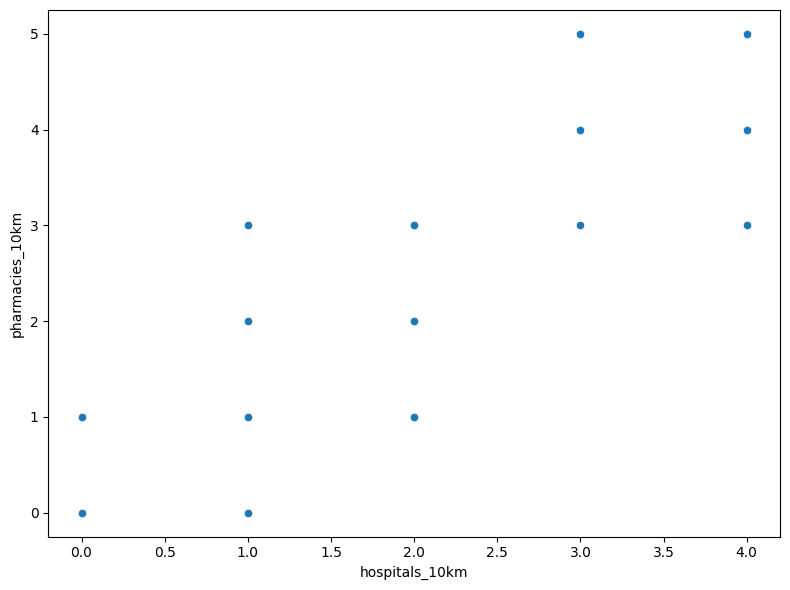

As indicated earlier from the heatmap, 5 numerical columns (internalFacilitiesCount	hospitals_10km	pharmacies_10km	facilityDiversity_10km	facilityDensity_10km) have 0.8 and above correlation coefficients which indicates that these variables are important for model training i.e Kmean Clustering. 

However, using only the correlation test wont be sufficient in selecting features. Therefore, VarianceThreshold would be applied to filter out features that have very low variance. Features with a training-set variance lower than this threshold will be removed. The default is to keep all features with non-zero variance, i.e. remove the features that have the same value in all samples.

The VarianceThreshold function is a selection algorithmn that looks at only the X features. This makes it perfect for unsupervised learning such as Kmeans, Kmedians and DBSCAN to name a few. At a set variance threshold, any feature's variance that is equal or lower than the predefined threshold is dropped.

However, from the list [0, 0.1, 0.2, 0.3] of thresholds as well as applying to both unscaled and scaled dataset, all the selected features show great promise in impacting our model. Hence, all the variables will be adopted in the training of our Kmeans clustering. 

The StandardScaler() function is applied to the dataset. This results in a numpy array which was saved in a pandas dataframe to preserve the column names. The Standardization of the dataset is very crucial because it subtracts the mean value then divides the result by the standard deviation. This achieves a mean of zero and standard deviation of 1. There are other scaling methods but this is not affected by ouliers.

# K-MEANS CLUSTERING

For this project, the KMeans clustering algorithm - also known as the Lloyd-Forgy algorithm - will be adopted. This is an unsupervised tasks in getting various unlabelled groups in a dataset. The number of clusters k must be specified for the algorithm to find and for this project 3 is the number. However, this might not be the most efficient way of determining the number of clusters in the dataset. 

To confirm the best value of k, the experiment of searching between 2 to 6 clusters was sdopted to get the Kmeans score/Inertia and the silohette scores. A rule of thumb to determine the best cluster is to look at the Kmeans Score graph and see the cluster at the elbow point. Also, the higher the silhoutte score, the better the cluster is. Looking at our graph below, we can see that the cluster at the elbow is 3 and looking at the silhoutte score at that cluster is approximately 0.55 which infact is the second highest. However, it is safe to say conclude that 3 clusters is most appropriate with the combination of these two factors. 

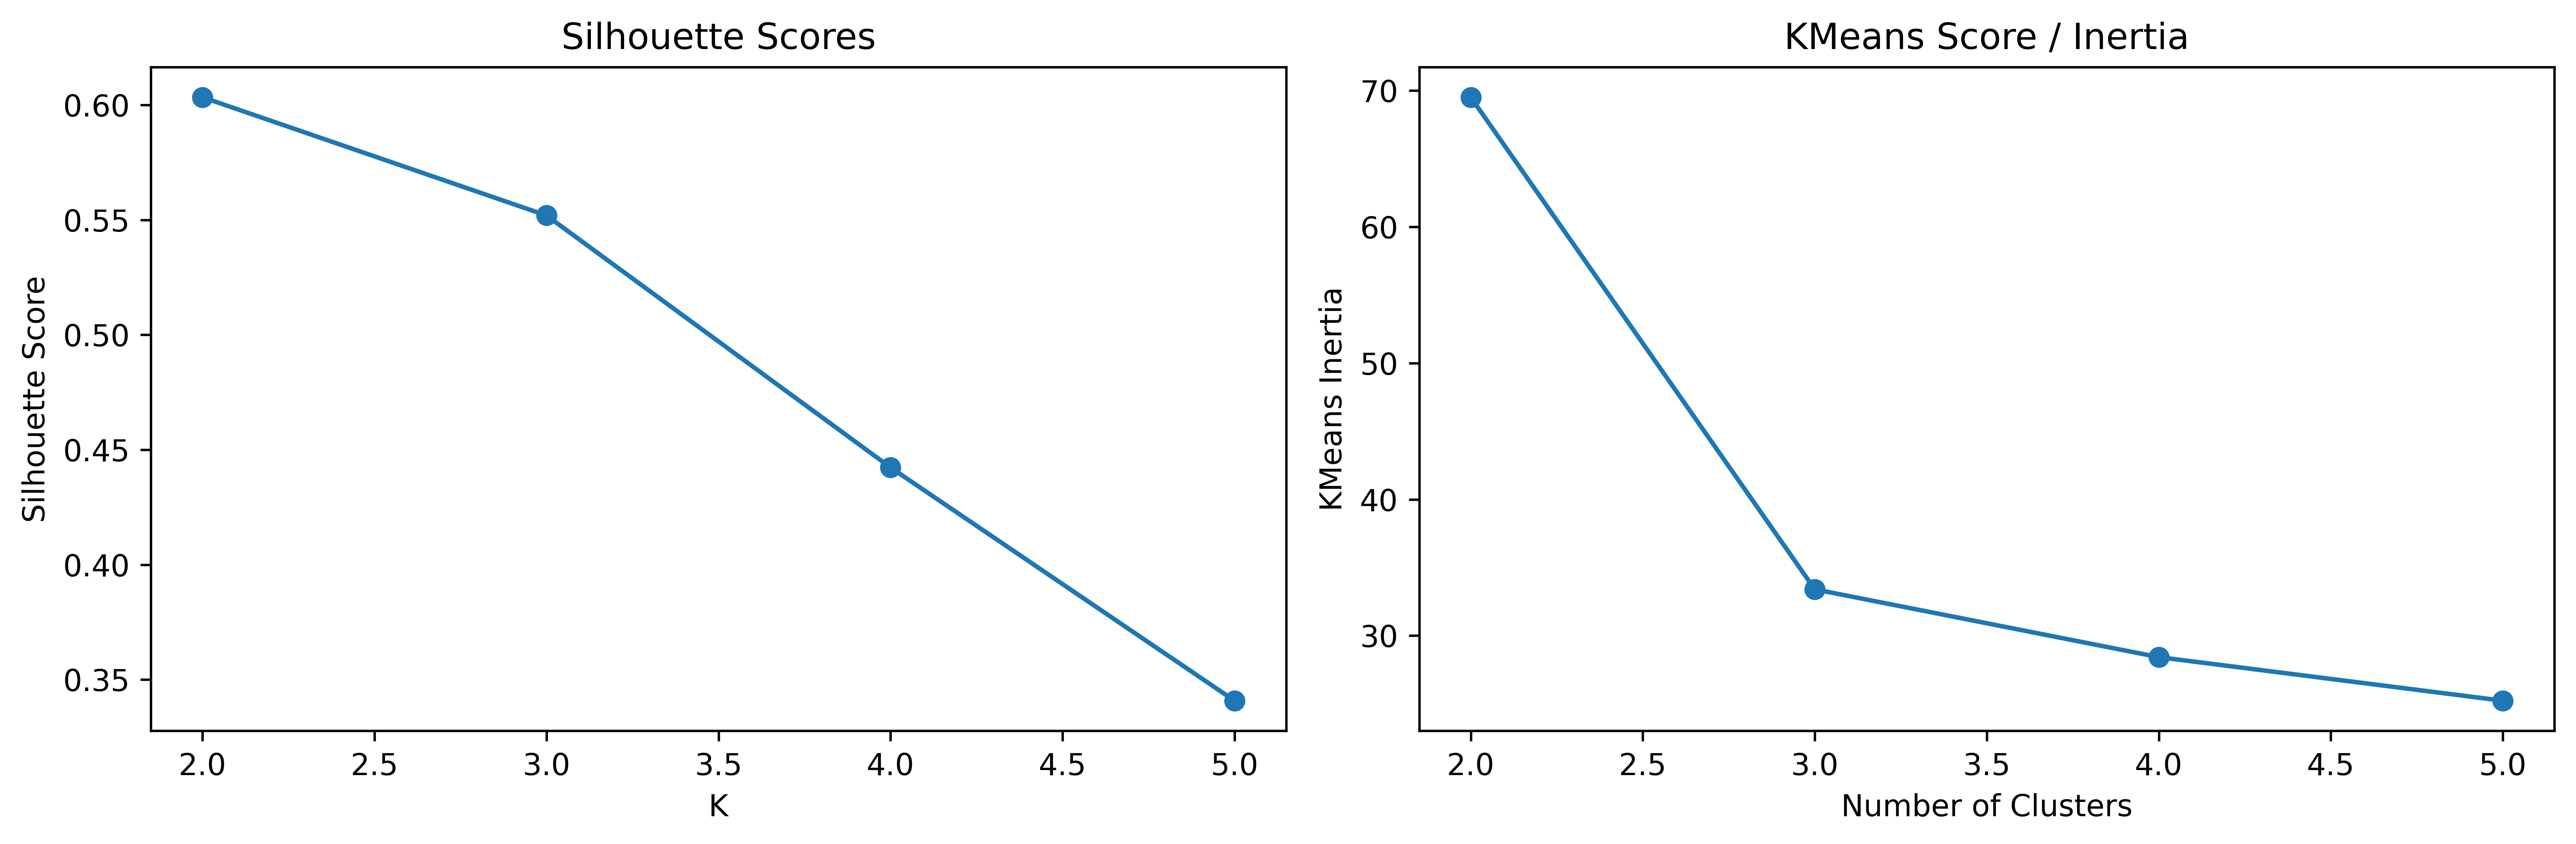

Looking at the Kmeans model below, setting the n_clusters to 3 as we have decided, the random_state to 42 to ensure reproducibility. The n_init was set to 20 (default is 10) to help run the algorithm multiple times with different random initiatization and the best solution is kept.

```
kmeans = KMeans(n_clusters=3, n_init = 20, random_state= 42)
```

# Save the Kmeans model with for K = 3  in a pickle file. 

The **make_pipeline** function which helps to automatically name the process and apply the various steps in a pipeline was adopted. It combines the StandardScaler step, the Variance Threshold and the Kmeans clustering steps together. This will ensure that the model and the preprocessing steps are saved for prediction and when applied in the app.py file.

N/B - when saving the model as shown below, the selected features were also saved in order to build the BaseModel flow properly with pandas and not run into issues

```
joblib.dump({
    "pipeline": pipeline,
    "selected_features": research_center_columns.columns[pipeline.named_steps["variancethreshold"].get_support()].tolist()
}, "kmeans_pipeline_model.pkl")
```
# Feature Impact in Percentages

| Feature                   | Impact Score | Impact (%) |
|----------------------------|-------------|------------|
| internalFacilitiesCount    | 9.902449    | 72.0%      |
| pharmacies_10km            | 2.839184    | 20.6%      |
| hospitals_10km             | 1.796327    | 13.1%      |
| facilityDiversity_10km     | 0.062256    | 0.45%      |
| facilityDensity_10km       | 0.033       | 0.2



The **internalFacilitiesCount** has by far the largest impact on classification, contributing about 72% of the total importance.  Proximity to pharmacies and hospitals also matter but are much less influential (20.6% and 13.1%, respectively).  **Facility diversity** and **facility density** have minimal effect, with their combined contributing less than 1% to the overall impact.

After training the Kmeans Clustering model, the .get_suuport() shows which features are crucial and which are not. Then the features are extracted to calculate the variance and finally order from highest to lowest.

From the correlation matrix and variance threshold experiments, it is clear that **`internalFacilitiesCount`** has the **highest impact** in classifying research facilities.  While proximity to pharmacies and hospitals also contributes, their impact is noticeably smaller, and even combining their scores does not surpass the effect of internal facilities.  Other features such as facility diversity and density have minimal influence on the classification outcome.

# Map cluster numbers to descriptive labels (Premium, Standard, Basic).

The list comprehension method was adopted to complete the task of mapping the clusters to different classes. There are other methods that will get the job done. 

```
cluster_class = ['Premium' if i == 0 else 'Standard' if i == 1 else 'Basic' if i == 2 else 'other' for i in pred_pipe]
```


The pred_pipe are the clusters predicted which is then deployed to map it to the 3 labels (to match the 3 clusters or k choosen).The cluster and the cluster class are mapped to the research_center dataframe
```
pred_pipe = pipeline.fit_predict(research_center_columns)
```

Standard research centers have the most robust internal infrastructure with an average of about 10 internal facilities, and the best access to external healthcare, with 3 hospitals and 4 pharmacies within 10 km, making them the top-performing tier in terms of facilities and healthcare proximity.    Premium centers are moderately equipped, with an average of 
5 internal facilities, 2 hospitals, and 2 pharmacies within 10 km. Basic centers have limited internal facilities two and poor external healthcare access  1 hospital and 1 pharmacies within 10 km.

High-quality research centers are somewhat concentrated in specific cities. City 1 hosts the most Premium centers (6) and also has 4 Standard centers, making it a hub for top-tier facilities. City 3 has 5 Premium and 4 Standard centers, showing another area with a strong presence of high-quality centers. City 4 has more Basic centers (5) but still maintains 4 Standard centers, indicating mixed quality. City 2 and City 5 have fewer high-quality centers, with 2–3 Premium and 2–3 Standard each, suggesting a more even distribution. Overall, City 1 and City 3 clearly host the majority of high-quality centers, highlighting some geographic clustering of top-tier research facilities.



# Average Feature Values per Cluster
| Cluster  | internalFacilitiesCount | hospitals_10km | pharmacies_10km | facilityDiversity_10km | facilityDensity_10km |
|---------|------------------------|----------------|----------------|------------------------|---------------------|
| Standard | 9.529412               | 3.470588       | 4.117647       | 0.850424               | 0.536852            |
| Basic    | 4.941176               | 1.529412       | 2.058824       | 0.559935               | 0.289845            |
| Premium  | 2.312500               | 0.500000       | 0.437500       | 0.279126               | 0.125271            |

# Summary

If I had real data, I would improve the clustering model by focusing on data quality, model comparison, and cluster validation. First, I would carefully preprocess the data—handling missing values, scaling features, and managing outliers—because real-world data is messy compared to synthetic data. Then, I would compare multiple clustering algorithms such as K-Means, K-Medoids, DBSCAN, and Agglomerative Clustering, tuning their hyperparameters using internal metrics like silhouette score . I would assess cluster stability by running models on different subsets of the data and checking consistency. Finally, I would validate the clusters using dimensionality reduction techniques like PCA or t-SNE to visualize separation and ensure the clusters are meaningful and actionable.

---


In [2]:
# import the data 
research_center = pd.read_csv('research_centers.csv')
research_center.head()

,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983


In [3]:
# Use .info() to get a general description of the data i.e the rows, attributes of each column and number of missing values
research_center.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   researchCenterId         50 non-null     object 
 1   researchCenterName       50 non-null     object 
 2   city                     50 non-null     object 
 3   latitude                 50 non-null     float64
 4   longitude                50 non-null     float64
 5   internalFacilitiesCount  50 non-null     int64  
 6   hospitals_10km           50 non-null     int64  
 7   pharmacies_10km          50 non-null     int64  
 8   facilityDiversity_10km   50 non-null     float64
 9   facilityDensity_10km     50 non-null     float64
dtypes: float64(4), int64(3), object(3)
memory usage: 4.0+ KB


In [4]:
research_center.describe()

,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,50.542770,-1.554638,5.660000,1.860000,2.240000,0.568843,0.321164
std,0.320289,0.253853,3.146816,1.340271,1.684988,0.249511,0.182562
min,50.007100,-1.976900,1.000000,0.000000,0.000000,0.119515,0.056541
25%,50.240375,-1.747225,3.000000,1.000000,1.000000,0.344145,0.173814
50%,50.635350,-1.561000,5.000000,2.000000,2.000000,0.585503,0.297584
75%,50.831475,-1.374175,8.750000,3.000000,3.000000,0.800489,0.476387
max,50.994600,-1.049300,11.000000,4.000000,5.000000,0.992984,0.697016


# Check for duplicates

In [5]:
research_center.duplicated().any()

False

# Check the historgram of the datasets

```

Visualize facility counts, diversity, and density across cities.
Explore correlations between numeric variables.
Identify which variables seem most important for determining research center quality.

```

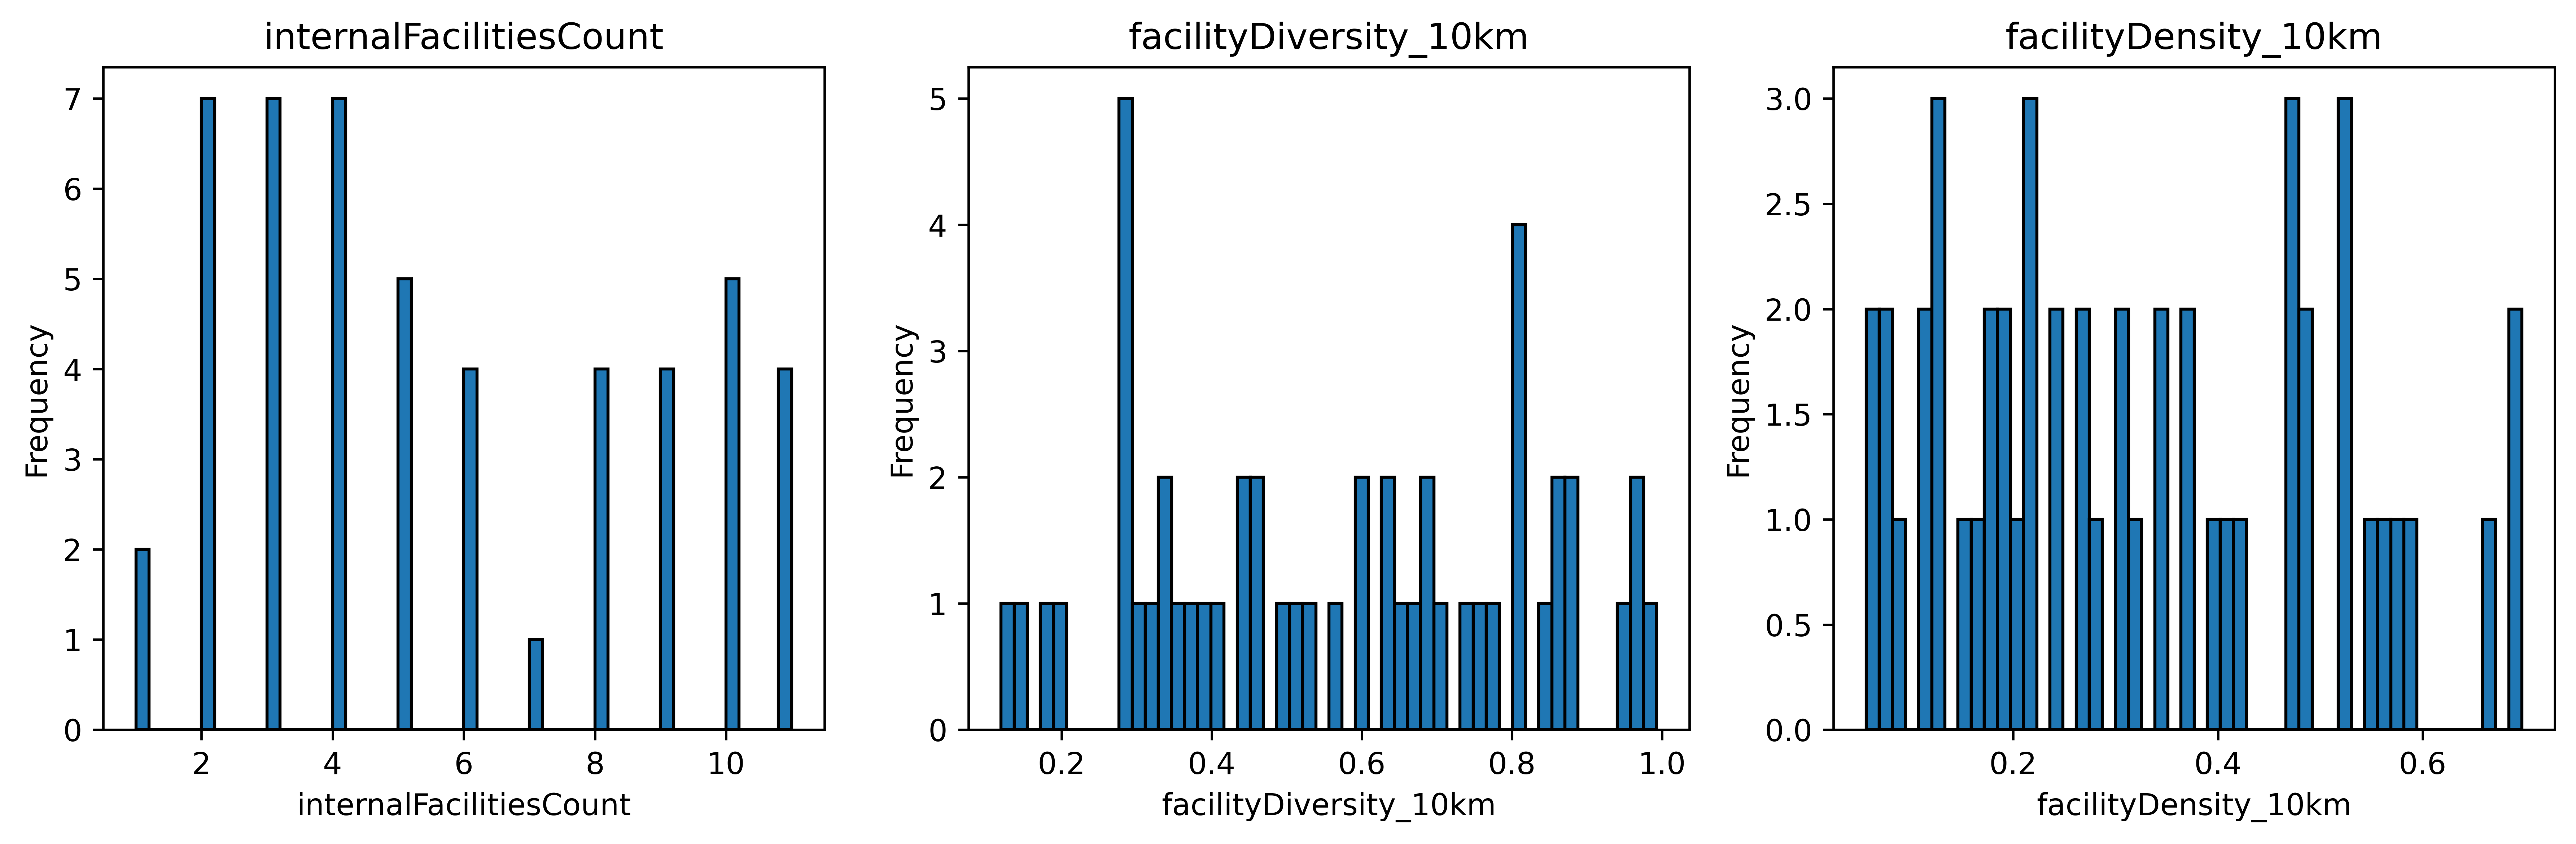

In [6]:
cols = ['internalFacilitiesCount', 'facilityDiversity_10km', 'facilityDensity_10km']

with sns.plotting_context(rc=dict(font='Roboto', palette=color_palette)):

    fig, axes = plt.subplots(1, 3, dpi=600, figsize=(12,4))

    for ax, col in zip(axes, cols):
        research_center[col].plot.hist(
            bins=50,
            ax=ax,
            edgecolor='black'
        )

        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
        ax.set_title(col)

    plt.tight_layout()
    fig.savefig('research_center_hist.png', dpi=600, bbox_inches='tight')

# Correlation heatmap of numeric columns

---
From the heatmap below, it is very clear that both longitude and latitude have very low correlations with other variables. This is not surprising as they are coordinates and they will therefore be dropped from the analysis going forward. 

The other five numerical data types all have high correlation coefficients with the lowest coming at 0.80. However, Internal Facilities Count have higher correlation to each of the other variables with its lowest at 0.88 and highest at 0.90. This shows that this variable might have the highest impact on our proposed model(Kmeans). This will be verified with VarianceThreshold function which is a filtering method both before and after training the model.

---

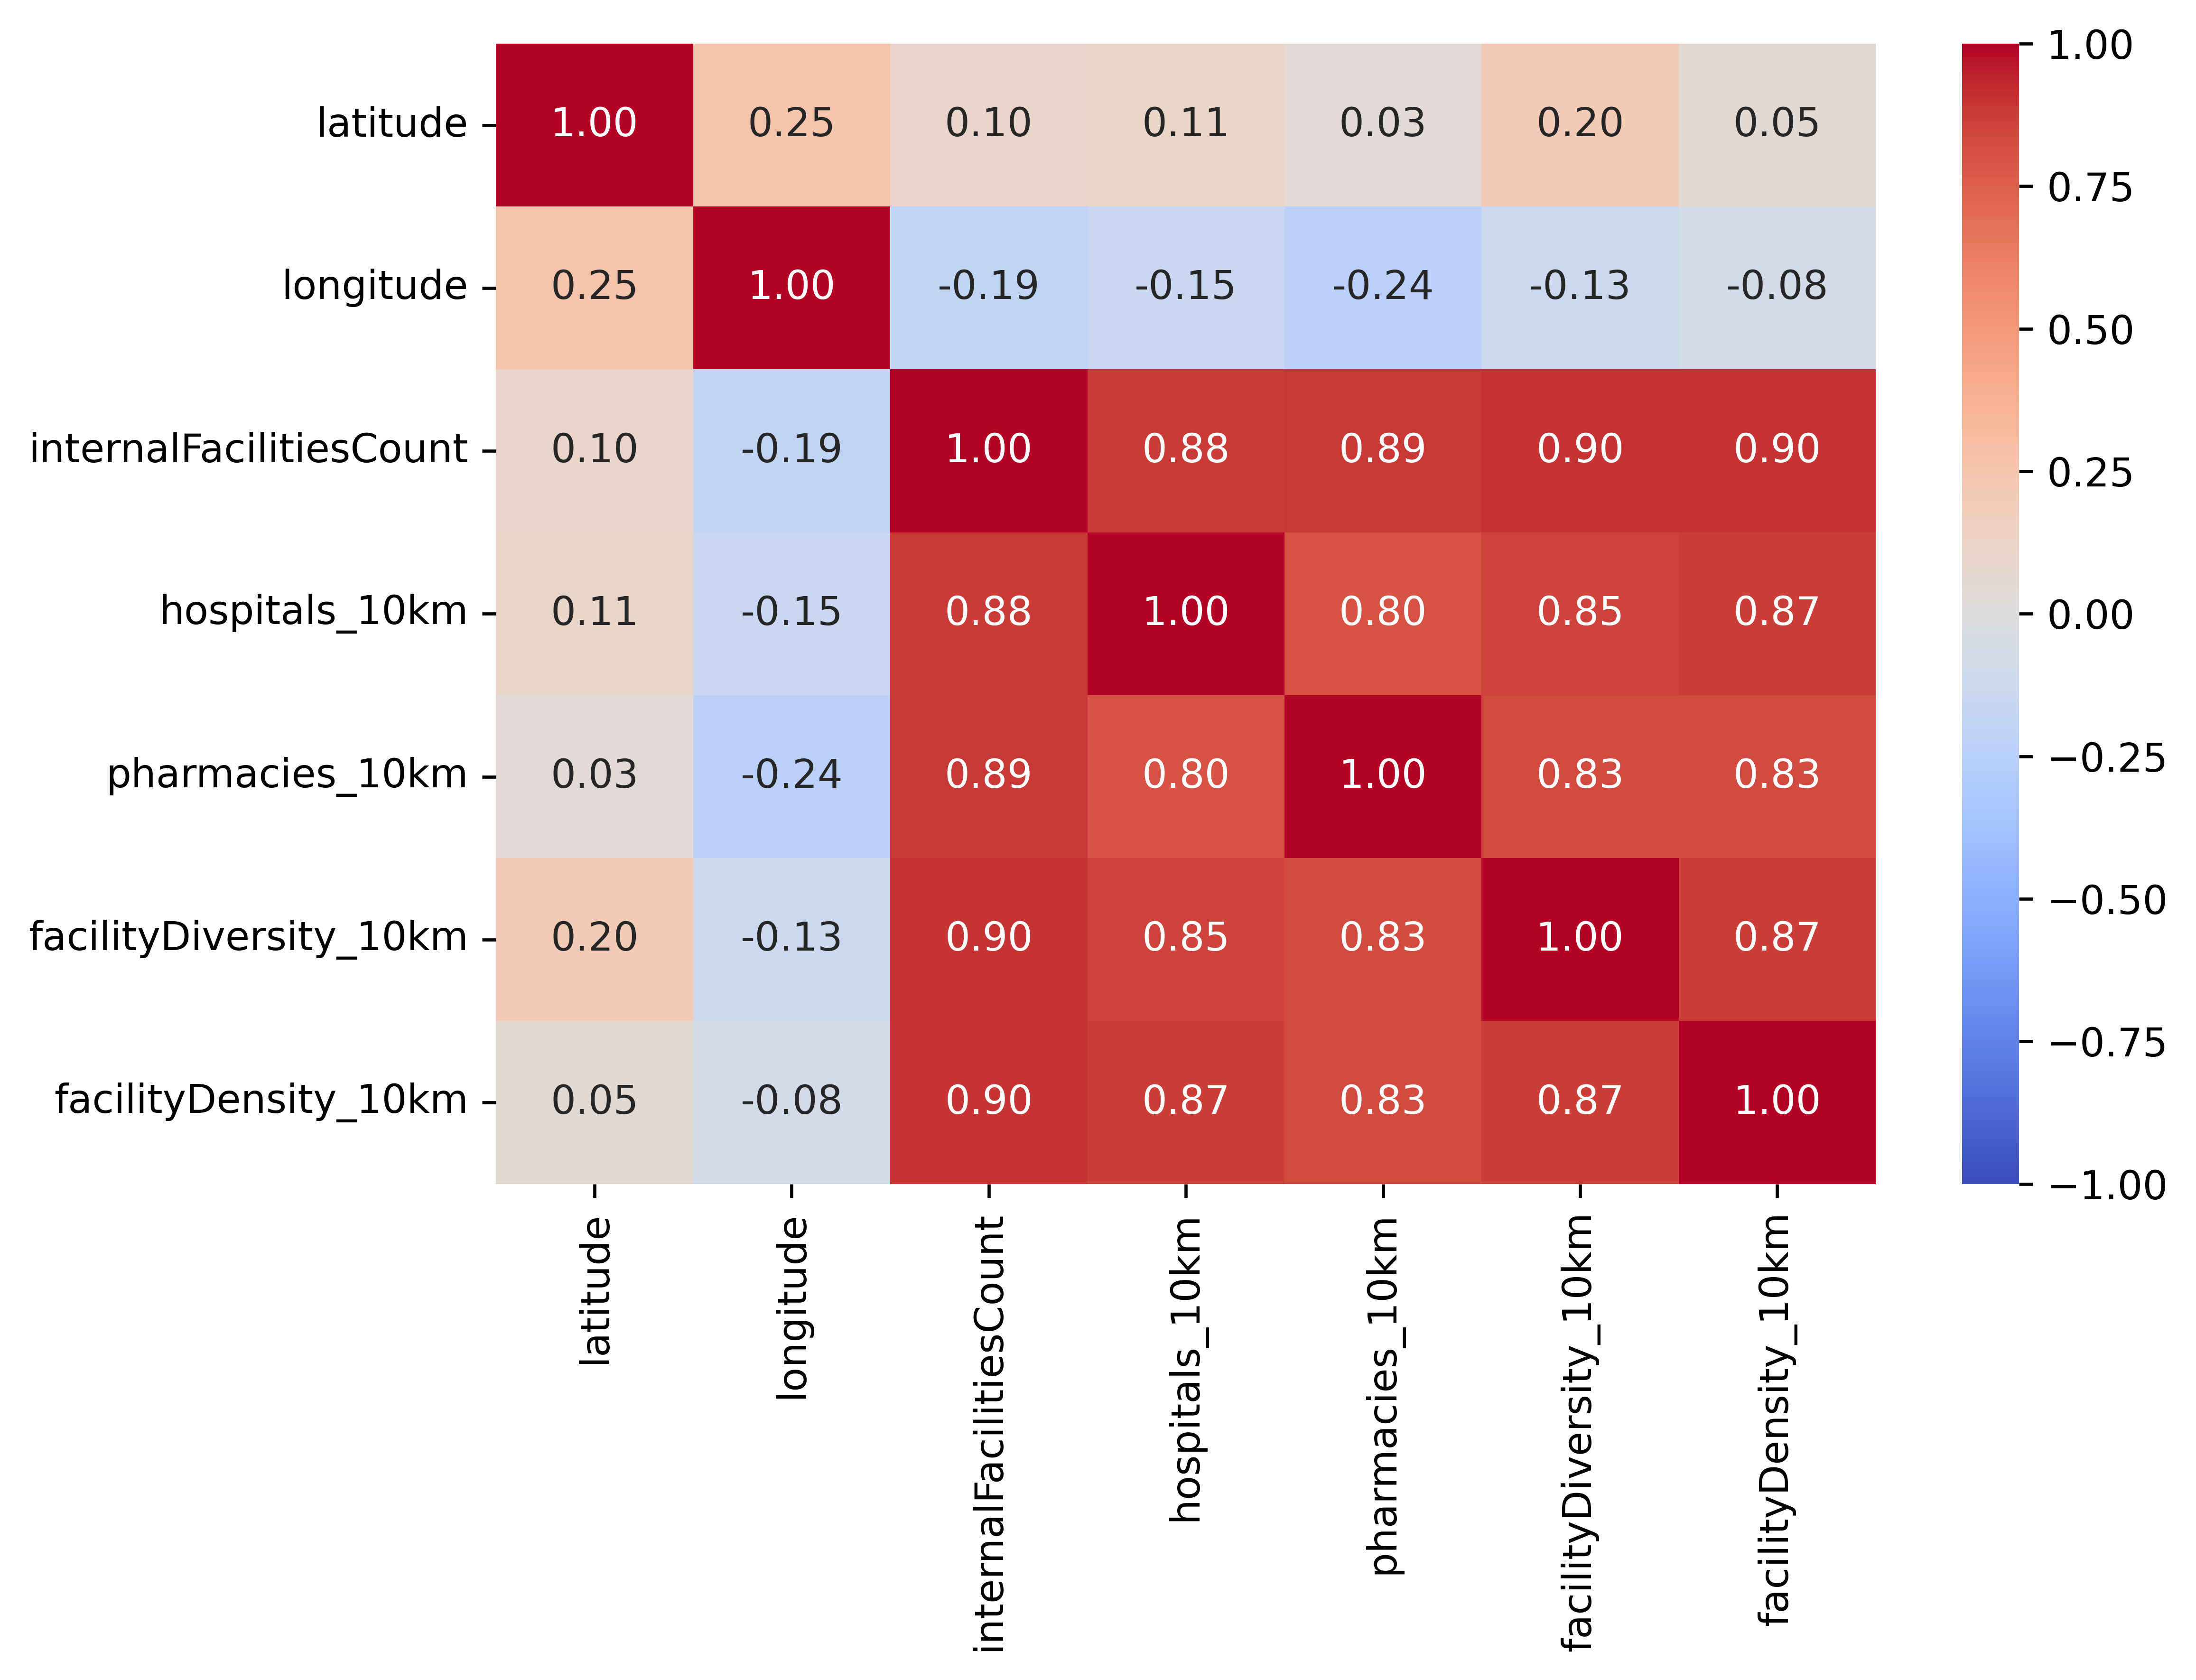

In [7]:
num_cols = research_center.select_dtypes(include='number')
corr = num_cols.corr()

fig, ax = plt.subplots(figsize=(8,6), dpi=600)

# Plot the Correlation Matrix
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1, ax=ax)

plt.tight_layout()

fig.savefig("research_center_corr_heatmap.png", dpi=600, bbox_inches="tight")

# Scatter plots showing hospital and pharmacy access.

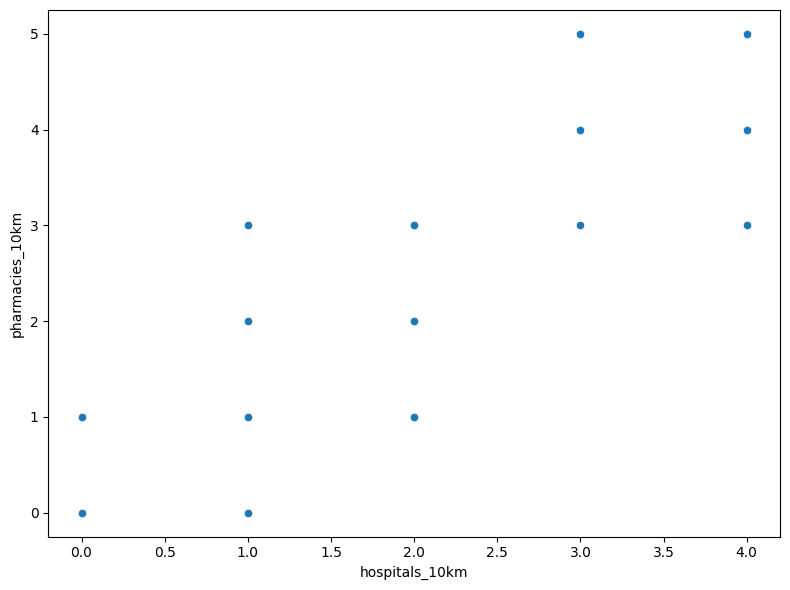

In [8]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=research_center, x='hospitals_10km', y='pharmacies_10km')
plt.tight_layout()
fig.savefig("hospital and pharmacy access.png", bbox_inches="tight")

In [9]:
cols = ['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km', 'facilityDiversity_10km', 'facilityDensity_10km']

research_center_columns = research_center[cols]

# VarianceThreshold

---

Features with a training-set variance lower than this threshold will be removed. The default is to keep all features with non-zero variance, i.e. remove the features that have the same value in all samples.


The VarianceThreshold function is a selection algorithmn that looks at only the X features. This makes it perfect for unsupervised learning such as Kmeans, Kmedians and DBSCAN to name a few. at a set variance threshold, any feature's variance that is equal or lower than the predefined threshold is dropped.

However, from the list [0, 0.1, 0.2, 0.3] of thresholds as well as applying to both unscaled and scaled dataset, all the selected features show great promise in impacting our model. Hence, all the variables will be adopted in the training of our Kmeans clustering.

---

In [10]:
def threshold(data, thres):
    """ 
    This function removes columns with variables with variance less than or equals the set threshold.

    It returns the dataframe of the remaining columns 
    """
    selector = VarianceThreshold(threshold=0)
    selector.fit(data)

    # Get the indices of features with high variance
    high_variance_indices = selector.get_support(indices=True)
    
    # Subset your data with selected features
    selected_data = data.iloc[:, high_variance_indices]

    return selected_data

In [11]:
thresh = [0, 0.1, 0.2, 0.3]

for i in thresh:
    print(i)
    selected_data = threshold(data=research_center_columns, thres = i)
    display(selected_data.head(2))

0


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,3,1,0,0.374488,0.177506
1,2,1,1,0.391903,0.108965


0.1


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,3,1,0,0.374488,0.177506
1,2,1,1,0.391903,0.108965


0.2


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,3,1,0,0.374488,0.177506
1,2,1,1,0.391903,0.108965


0.3


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,3,1,0,0.374488,0.177506
1,2,1,1,0.391903,0.108965


# Standardize the data and check the threshold again

---
The StandardScaler() function is applied to the dataset. This results in a numpy array which was saved in a pandas dataframe to preserve the column names. The Standardization of the dataset is very crucial because it subtracts the mean value then divides the result by the standard deviation. This achieves a mean of zero and standard deviation of 1. There are other scaling methods but this is not affected by ouliers.

---

In [12]:
std_scaler =  StandardScaler()
research_center_scaled = std_scaler.fit_transform(research_center_columns)

# Convert back to DataFrame, preserving column names
research_center_scaled_df = pd.DataFrame(research_center_scaled, columns=research_center_columns.columns)

In [13]:
for i in thresh:
    print(i)
    selected_data = threshold(data=research_center_scaled_df , thres = i)
    display(selected_data.head(2))

0


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,-0.853881,-0.648176,-1.342883,-0.786850,-0.794887
1,-1.174889,-0.648176,-0.743382,-0.716344,-1.174139


0.1


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,-0.853881,-0.648176,-1.342883,-0.786850,-0.794887
1,-1.174889,-0.648176,-0.743382,-0.716344,-1.174139


0.2


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,-0.853881,-0.648176,-1.342883,-0.786850,-0.794887
1,-1.174889,-0.648176,-0.743382,-0.716344,-1.174139


0.3


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,-0.853881,-0.648176,-1.342883,-0.786850,-0.794887
1,-1.174889,-0.648176,-0.743382,-0.716344,-1.174139


# K-MEANS CLUSTERING

---
For this project, the KMeans clustering algorithm - also known as the Lloyd-Forgy algorithm - will be adopted. This is an unsupervised tasks in getting various unlabelled groups in a dataset. The number of clusters k must be specified for the algorithm to find and for this project 3 is the number. However, this might not be the most efficient way of determining the number of clusters in the dataset. 

To confirm the best value of k, the experiment of searching between 2 to 6 clusters was sdopted to get the Kmeans score/Inertia and the silohette scores. A rule of thumb to determine the best cluster is to look at the Kmeans Score graph and see the cluster at the elbow point. Also, the higher the silhoutte score, the better the cluster is. Looking at our graph below, we can see that the cluster at the elbow is 3 and looking at the silhoutte score at that cluster is approximately 0.55 which infact is the second highest. However, it is safe to say conclude that 3 clusters is most appropriate with the combination of these two factors. 

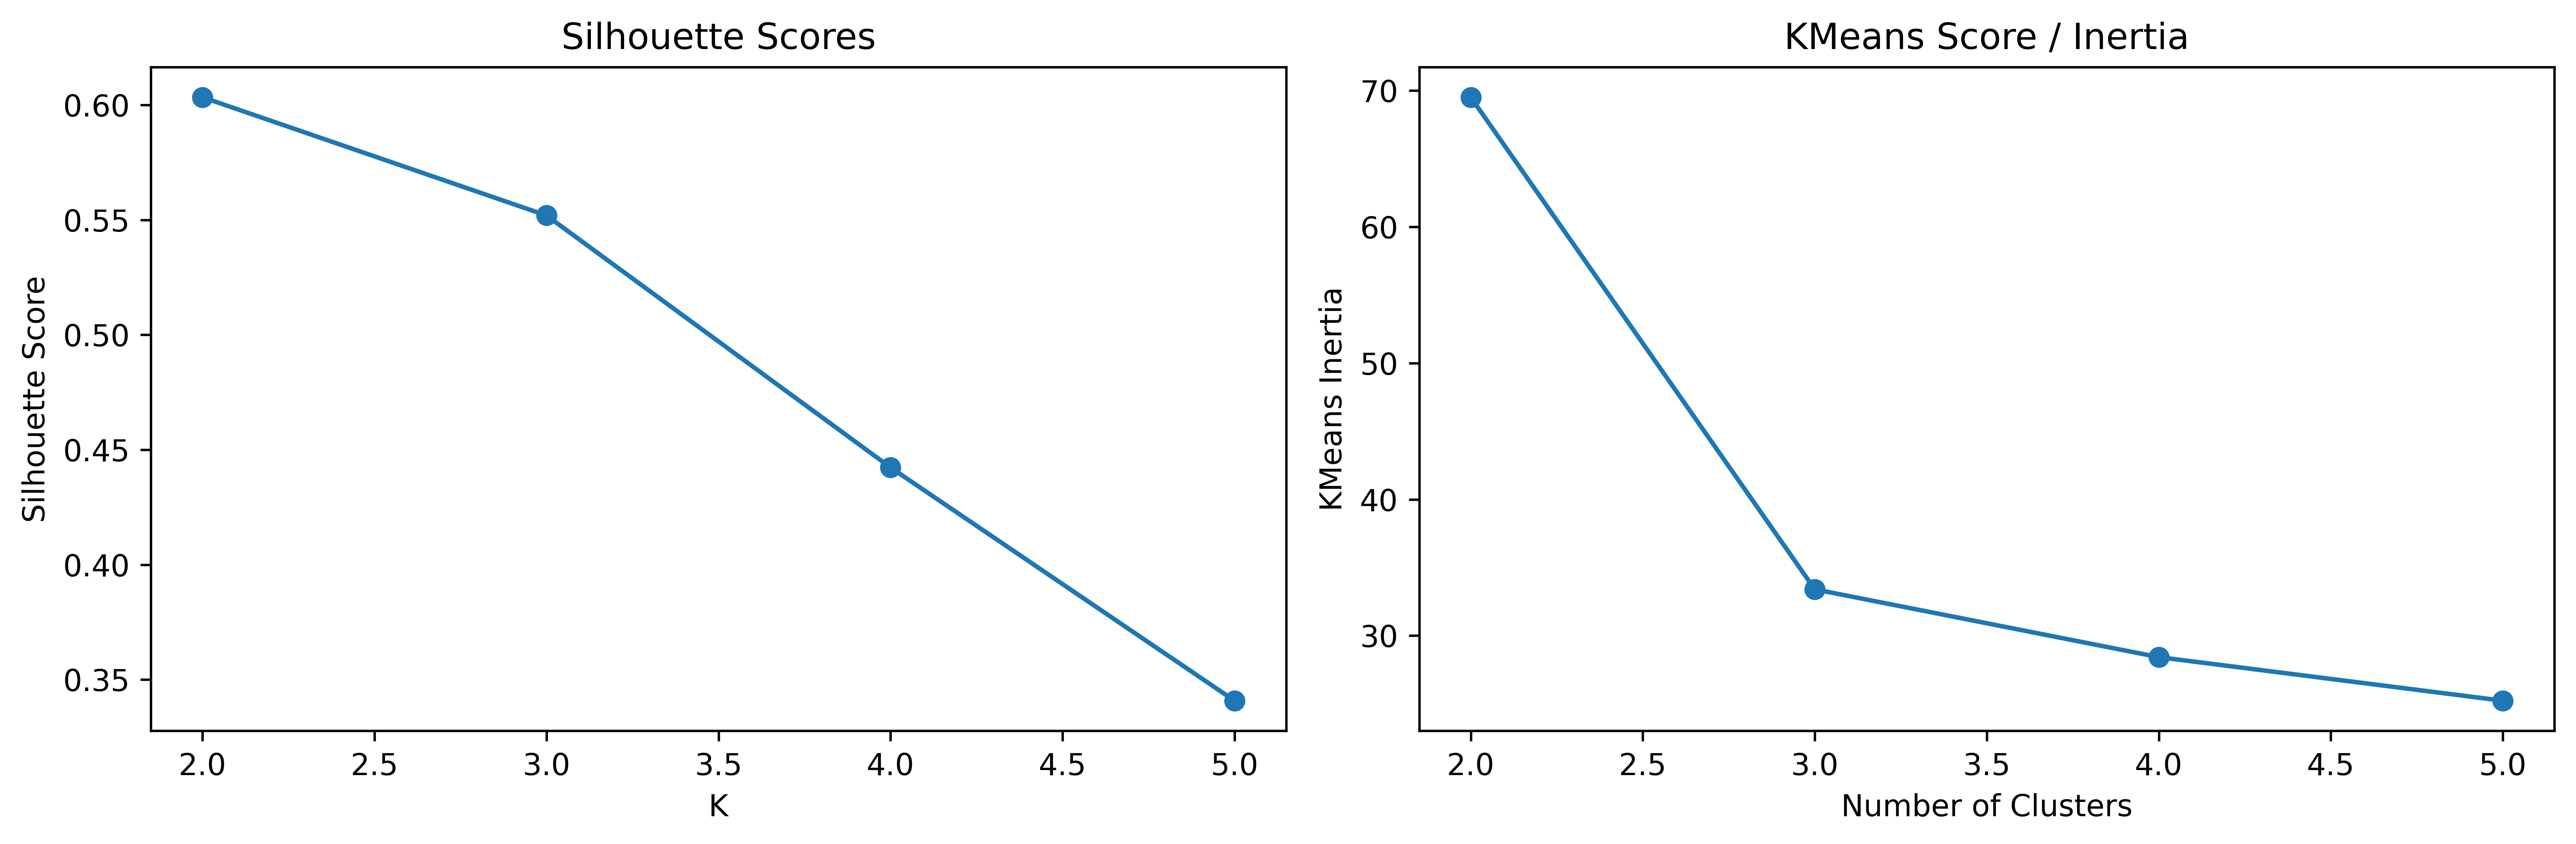

Looking at the Kmeans model below, setting the n_clusters to 3 as we have decided, the random_state to 42 to ensure reproducibility. The n_init was set to 20 (default is 10) to help run the algorithm multiple times with different random initiatization and the best solution is kept.

```
kmeans = KMeans(n_clusters=3, n_init = 20, random_state= 42)
```

---

The Kmeans score for 2 clusters is 69.50774423084755
The silhouette score for 2 clusters is 0.6033552952369612


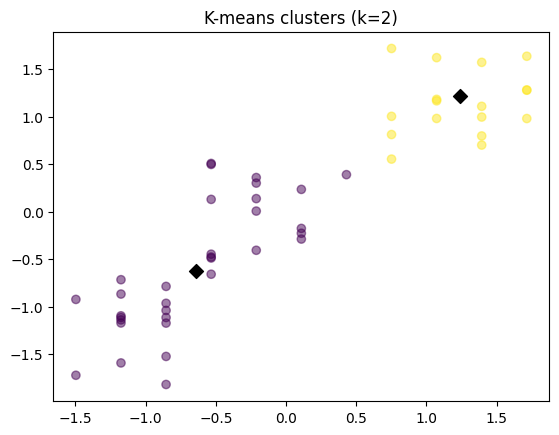

----------------------------------------------------------------------------------------
The Kmeans score for 3 clusters is 33.40223751449422
The silhouette score for 3 clusters is 0.5519201011808984


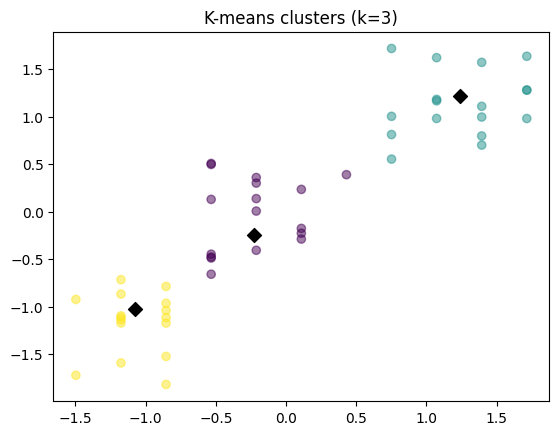

----------------------------------------------------------------------------------------
The Kmeans score for 4 clusters is 28.426543692508574
The silhouette score for 4 clusters is 0.4422920935572649


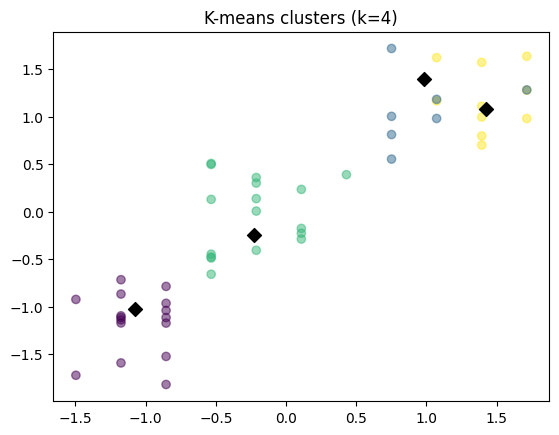

----------------------------------------------------------------------------------------
The Kmeans score for 5 clusters is 25.23092815609616
The silhouette score for 5 clusters is 0.3408209991306616


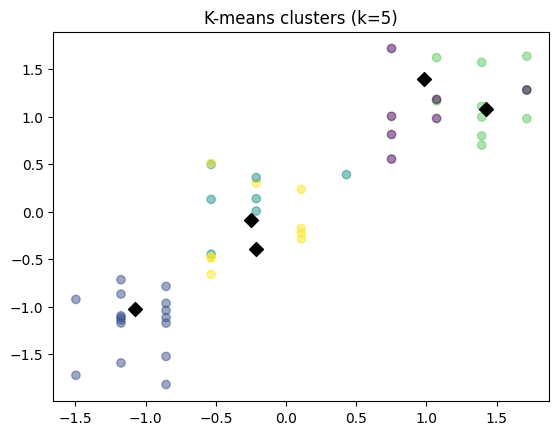

----------------------------------------------------------------------------------------


In [14]:
clusters = []
silhouette_scores = []
inertias = []

for cluster in range(2,6):
    kmeans = KMeans(n_clusters=cluster, n_init = 20, random_state= 42)
    pred = kmeans.fit_predict(research_center_scaled)
    labels = pred
    centroids = kmeans.cluster_centers_

    inertias.append(kmeans.inertia_)
    clusters.append(cluster)
    print(f'The Kmeans score for {cluster} clusters is {kmeans.inertia_}')
    
    sil_score = silhouette_score(research_center_scaled, kmeans.labels_)
    print(f'The silhouette score for {cluster} clusters is {sil_score}')
    silhouette_scores.append(sil_score)
    
    # Plot # ── Plot (first 2 features on axes) ───────────────────────────────────────────
    xs = research_center_scaled[:, 0]
    ys = research_center_scaled[:, 3]
    
    plt.scatter(xs, ys, c=labels, alpha=0.5)
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='D', s=50, color='black')
    plt.title(f"K-means clusters (k={cluster})")
    plt.show()
    print("----------------------------------------------------------------------------------------")

# Silhoutte Scores and Inertia

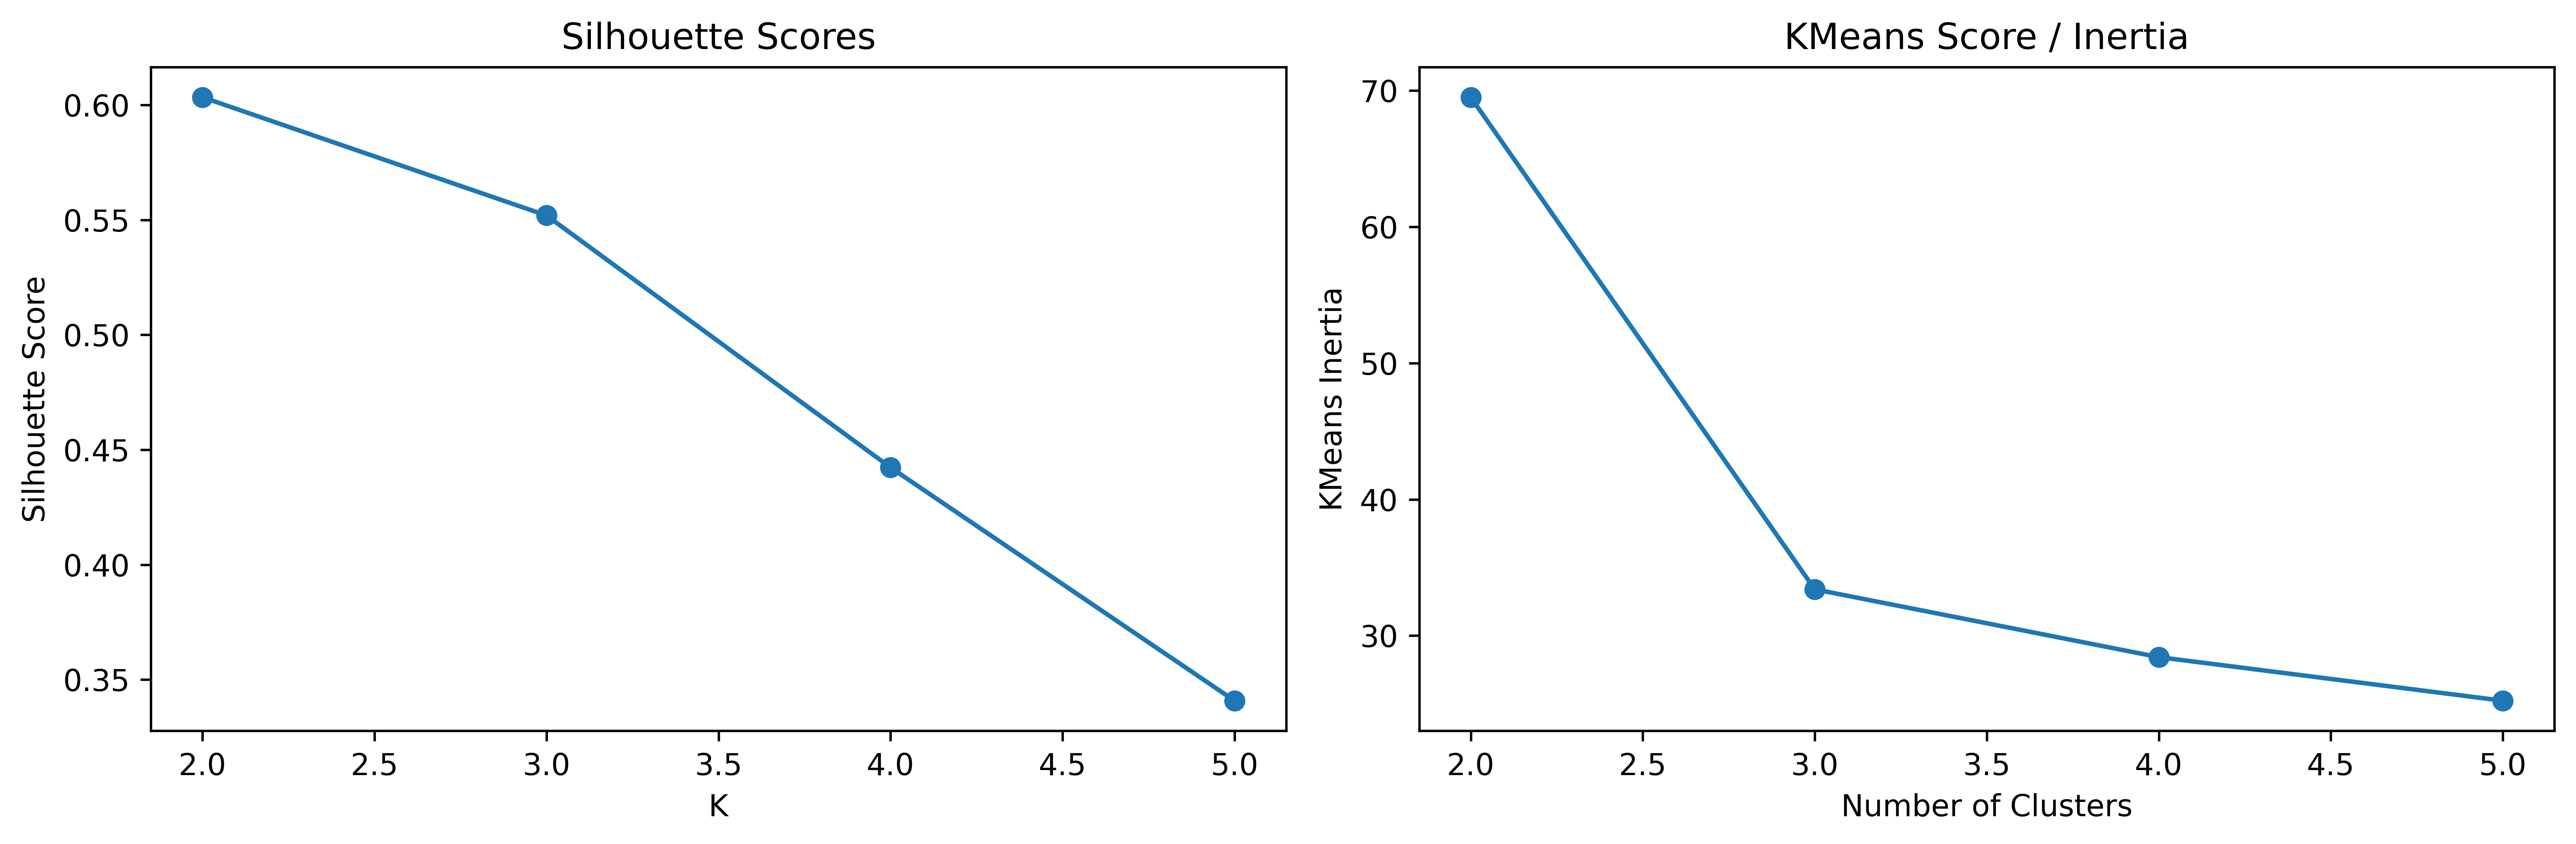

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), dpi=600)

# Silhouette score plot
axes[0].plot(clusters, silhouette_scores, marker='o')
axes[0].set_xlabel("K")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Silhouette Scores")

# Inertia plot
axes[1].plot(clusters, inertias, marker='o')
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("KMeans Inertia")
axes[1].set_title("KMeans Score / Inertia")

plt.tight_layout()

fig.savefig("clustering_evaluation.png", dpi=600, bbox_inches="tight")

plt.show()

# Save the Kmeans model with for K = 3  in a pickle file. 

---
The make_pipeline function which helps to automatically name the process and apply the various steps in a pipeline was adopted. It combines the StandardScaler step, the Variance Threshold and the Kmeans clustering steps together. This will ensure that the model and the preprocessing steps are saved for prediction and when applied in the app.py file.

N/B - when savind the model as shown below, the selected features were also saved in order to build the BaseModel flow properly with pandas and not run into issues

```
joblib.dump({
    "pipeline": pipeline,
    "selected_features": research_center_columns.columns[pipeline.named_steps["variancethreshold"].get_support()].tolist()
}, "kmeans_pipeline_model.pkl")
```

---

In [16]:
pipeline = make_pipeline(
    StandardScaler(),
    VarianceThreshold(),
    KMeans(n_clusters=3, n_init=20, random_state=42)
)

pipeline.fit(research_center_columns)

joblib.dump({
    "pipeline": pipeline,
    "selected_features": research_center_columns.columns[pipeline.named_steps["variancethreshold"].get_support()].tolist()
}, "kmeans_pipeline_model.pkl")

['kmeans_pipeline_model.pkl']

In [17]:
# The label is also the pred
pred_pipe = pipeline.fit_predict(research_center_columns)
pred_pipe

array([2, 2, 2, 1, 1, 0, 2, 1, 2, 2, 2, 1, 1, 0, 1, 1, 2, 2, 0, 0, 2, 1,
       2, 1, 0, 2, 0, 1, 1, 2, 0, 2, 0, 0, 0, 1, 0, 0, 1, 2, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 2])

# Column that has the Highest Impact in Percentages

| Feature                   | Impact Score | Impact (%) |
|----------------------------|-------------|------------|
| internalFacilitiesCount    | 9.902449    | 72.0%      |
| pharmacies_10km            | 2.839184    | 20.6%      |
| hospitals_10km             | 1.796327    | 13.1%      |
| facilityDiversity_10km     | 0.062256    | 0.45%      |
| facilityDensity_10km       | 0.033       | 0.24%      |

**Discussion:**  
The **internalFacilitiesCount** has by far the largest impact on classification, contributing about 72% of the total importance.  
Proximity to pharmacies and hospitals also matter but are much less influential (20.6% and 13.1%, respectively).  
Facility diversity and density have minimal effect, each contributing less than 1% to the overall impact.

After training the Kmeans Clustering model, the .get_support() shows which features are crucial and which are not. Then the features are extracted to calculate the variance and finally order from highest to lowest.

From the correlation matrix and variance threshold experiments, it is clear that **`internalFacilitiesCount`** has the **highest impact** in classifying research facilities.  While proximity to pharmacies and hospitals also contributes, their impact is noticeably smaller, and even combining their scores does not surpass the effect of internal facilities.  Other features such as facility diversity and density have minimal influence on the classification outcome.stion outcome.assification.

In [18]:
# Mask of columns kept by VarianceThreshold
mask = pipeline.named_steps["variancethreshold"].get_support()

# Calculate variances of selected columns
kept_variances = research_center_columns.var()[mask]

# Rank from highest to lowest
ranked_columns = kept_variances.sort_values(ascending=False)

print(ranked_columns)

internalFacilitiesCount    9.902449
pharmacies_10km            2.839184
hospitals_10km             1.796327
facilityDiversity_10km     0.062256
facilityDensity_10km       0.033329
dtype: float64


# Map cluster numbers to descriptive labels (Premium, Standard, Basic).

---
The list comprehension method was adopted to complete the task of mapping the clusters to different classes. There are other methods that will get the job done. 

```
cluster_class = ['Premium' if i == 0 else 'Standard' if i == 1 else 'Basic' if i == 2 else 'other' for i in pred_pipe]
```


The pred_pipe are the clusters predicted which is then deployed to map it to the 3 labels (to match the 3 clusters or k choosen)
```
pred_pipe = pipeline.fit_predict(research_center_columns)
```

Finally, the cluster and the cluster class are mapped to the research_center dataframe

---

In [19]:
cluster_class = ['Premium' if i == 0 else 'Standard' if i == 1 else 'Basic' if i == 2 else 'other' for i in pred_pipe]

# Add the Cluster Class(Quality Tier) and the Cluster to the original Dataframe 

In [20]:
# The label is also the pred
research_center['cluster']	= pred_pipe 

# The mapped list
research_center['qualityTier'] = cluster_class

research_center.head(5)

,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km,cluster,qualityTier
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506,2,Basic
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965,2,Basic
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155,2,Basic
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016,1,Standard
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983,1,Standard


# Model Interpretation

Standard research centers have the most robust internal infrastructure with an average of about 10 internal facilities, and the best access to external healthcare, with 3 hospitals and 4 pharmacies within 10 km, making them the top-performing tier in terms of facilities and healthcare proximity.    
Premium centers are moderately equipped, with an average of
5  interna  facilitie*,23 hospital*, and*6 pharmacie* within 10 km.
Basic centers have limited internal facilitietwo*) and poor external healthcare acces 1 hospital and 1 pharmacies within 10 km.

High-quality research centers are somewhat concentrated in specific cities. City 1 hosts the most Premium centers (6) and also has 4 Standard centers, making it a hub for top-tier facilities. City 3 has 5 Premium and 4 Standard centers, showing another area with a strong presence of high-quality centers. City 4 has more Basic centers (5) but still maintains 4 Standard centers, indicating mixed quality. City 2 and City 5 have fewer high-quality centers, with 2–3 Premium and 2–3 Standard each, suggesting a more even distribution. Overall, City 1 and City 3 clearly host the majority of high-quality centers, highlighting some geographic clustering of top-tier research facilities.

### Average Feature Values per Cluster

| Cluster | internalFacilitiesCount | hospitals_10km | pharmacies_10km | facilityDiversity_10km | facilityDensity_10km |
|---------|------------------------|----------------|----------------|------------------------|---------------------|
| 1       | 9.529412               | 3.470588       | 4.117647       | 0.850424               | 0.536852            |
| 0       | 4.941176               | 1.529412       | 2.058824       | 0.559935               | 0.289845            |
| 2       | 2.312500               | 0.500000       | 0.437500       | 0.279126               | 0.125271         ---   |).--

In [21]:
#Which cluster has the highest internal facility counts and external healthcare access?
columns = ['internalFacilitiesCount',	'hospitals_10km',	'pharmacies_10km', 'qualityTier']
cluster_summary = research_center[columns]

# Group by cluster and compute mean values
cluster_summary = cluster_summary.groupby("qualityTier").mean(numeric_only=True)

# Sort for readability (optional)
cluster_summary = cluster_summary.sort_values(by="internalFacilitiesCount", ascending=False)

cluster_summary

,internalFacilitiesCount,hospitals_10km,pharmacies_10km
qualityTier,,,
Standard,9.529412,3.470588,4.117647
Premium,4.941176,1.529412,2.058824
Basic,2.312500,0.500000,0.437500


In [22]:
# Are high-quality centers concentrated in specific cities?
pd.crosstab(research_center["city"], research_center["qualityTier"])

qualityTier,Basic,Premium,Standard
city,,,
City 1,1,6,4
City 2,2,2,2
City 3,5,5,4
City 4,5,1,4
City 5,3,3,3


In [23]:
# Include summary tables showing the average feature values for each cluster.
features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km"
]

cluster_summary = research_center.groupby("qualityTier")[features].mean()

# Sort by internal facilities (proxy for quality)
cluster_summary = cluster_summary.sort_values(by="internalFacilitiesCount", ascending=False)

cluster_summary

,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
qualityTier,,,,,
Standard,9.529412,3.470588,4.117647,0.850424,0.536852
Premium,4.941176,1.529412,2.058824,0.559935,0.289845
Basic,2.312500,0.500000,0.437500,0.279126,0.125271
